# PyTorch: Multi-Label Classification using FastAI

Dataset: PASCAL

In [1]:
from fastai.vision.all import *
import pandas as pd

# Prepare Dataset

In [2]:
path = untar_data(URLs.PASCAL_2007)

In [3]:
df = pd.read_csv(path/"train.csv")
df.head()

,fname,labels,is_valid
0,000005.jpg,chair,True
1,000007.jpg,car,True
2,000009.jpg,horse person,True
3,000012.jpg,car,False
4,000016.jpg,bicycle,True


In [4]:
def splitter(df):
    train = df.index[~df["is_valid"]].to_list()
    valid = df.index[df["is_valid"]].to_list()
    return train,valid
def get_x(r): return path/"train"/r["fname"]
def get_y(r): return r["labels"].split(" ")

dls = dblock = DataBlock(
    blocks=(ImageBlock, MultiCategoryBlock),
    splitter=splitter,
    get_x=get_x,
    get_y=get_y,
    item_tfms=[RandomResizedCrop(128, min_scale=0.35)]
).dataloaders(df)

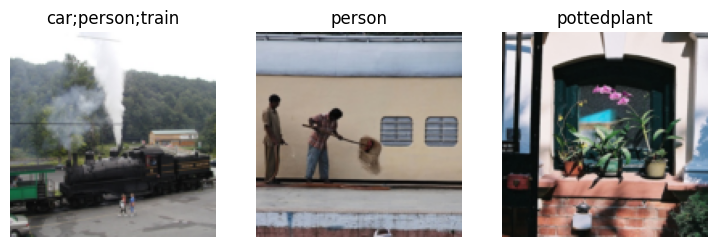

In [5]:
dls.show_batch(nrows=1, ncols=3)

# Train Model

In [79]:
def accuracy_multi(y_hat, y, threshold=0.5, sigmoid=True):
    if sigmoid: y_hat = y_hat.sigmoid()
    return ((y_hat>threshold)==y.bool()).float().mean()


In [ ]:
learn = vision_learner(dls, resnet50,
                       metrics=partial(accuracy_multi, threshold=0.2))

In [ ]:
learn.fine_tune(3, base_lr=3e-3, freeze_epochs=4)

In [ ]:
preds,targs = learn.get_preds()

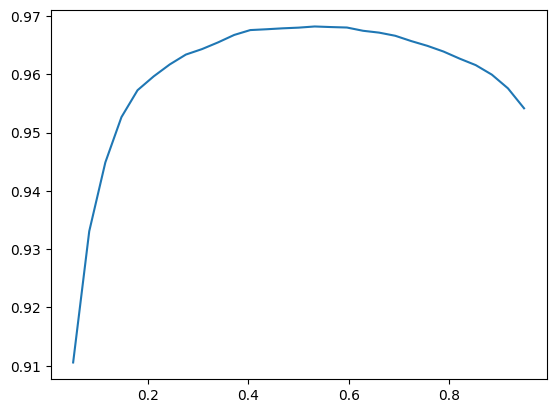

In [ ]:
# Plot accuracy with different thresholds (hyperparameter)
xs = torch.linspace(0.05,0.95,29)
accs = [accuracy_multi(preds, targs, threshold=i, sigmoid=False) for i in xs]
plt.plot(xs,accs);